In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Loading: Data & cleaning 

In [2]:
#Loading data
data = pd.read_csv("Student_Depression_Dataset.csv")

print(data.shape)
data.head()

(27901, 18)


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [5]:
data.columns
## For our writeup n = 27,901 observations
##p = 17 possible predictors

Index(['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure',
       'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression'],
      dtype='object')

In [7]:
data.isnull().sum()
data["Depression"].value_counts()

Depression
1    16336
0    11565
Name: count, dtype: int64

In [9]:
##Rename
predictors = [
    "Gender",
    "Age",
    "Academic Pressure",
    "CGPA",
    "Study Satisfaction",
    "Sleep Duration",
    "Dietary Habits",
    "Have you ever had suicidal thoughts ?",
    "Work/Study Hours",
    "Financial Stress",
    "Family History of Mental Illness"
]

X = data[predictors]
y = data["Depression"]

#dropping rows
df = pd.concat([X, y], axis=1).dropna()

X = df[predictors]
y = df["Depression"]

print(X.shape)
print(y.shape)

(27898, 11)
(27898,)


In [12]:
#columns into numbers
X_encoded = pd.get_dummies(X, drop_first=True)

X_encoded.head()

,Age,Academic Pressure,CGPA,Study Satisfaction,Work/Study Hours,Financial Stress,Gender_Male,Sleep Duration_7-8 hours,Sleep Duration_Less than 5 hours,Sleep Duration_More than 8 hours,Sleep Duration_Others,Dietary Habits_Moderate,Dietary Habits_Others,Dietary Habits_Unhealthy,Have you ever had suicidal thoughts ?_Yes,Family History of Mental Illness_Yes
0,33.0,5.0,8.97,2.0,3.0,1.0,True,False,False,False,False,False,False,False,True,False
1,24.0,2.0,5.90,5.0,3.0,2.0,False,False,False,False,False,True,False,False,False,True
2,31.0,3.0,7.03,5.0,9.0,1.0,True,False,True,False,False,False,False,False,False,True
3,28.0,3.0,5.59,2.0,4.0,5.0,False,True,False,False,False,True,False,False,True,True
4,25.0,4.0,8.13,3.0,1.0,1.0,False,False,False,False,False,True,False,False,True,False


In [13]:
#predictors
print("Number of predictors after encoding:", X_encoded.shape[1])

Number of predictors after encoding: 16


# Model 1 - Logistic Regression

In [14]:
demo_predictors = [
    "Gender",
    "Age",
    "Family History of Mental Illness"
]

X_demo = data[demo_predictors]
y_demo = data["Depression"]

df_demo = pd.concat([X_demo, y_demo], axis=1).dropna()

X_demo = df_demo[demo_predictors]
y_demo = df_demo["Depression"]

X_demo_encoded = pd.get_dummies(X_demo, drop_first=True)

log_demo = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

demo_scores = cross_val_score(
    log_demo,
    X_demo_encoded,
    y_demo,
    cv=kf,
    scoring="accuracy"
)

print("Demographic Model CV Accuracy Scores:", demo_scores)
print("Average Demographic Model Accuracy:", demo_scores.mean())

Demographic Model CV Accuracy Scores: [0.62085648 0.62616487 0.63207885 0.62562724 0.62867384]
Average Demographic Model Accuracy: 0.6266802560402389


## Full regression model

In [15]:
log_full = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

full_scores = cross_val_score(
    log_full,
    X_encoded,
    y,
    cv=kf,
    scoring="accuracy"
)

print("Full Logistic Regression CV Accuracy Scores:", full_scores)
print("Average Full Logistic Regression Accuracy:", full_scores.mean())

Full Logistic Regression CV Accuracy Scores: [0.84480287 0.84820789 0.84480287 0.84459581 0.85535042]
Average Full Logistic Regression Accuracy: 0.8475519693988144


## KKN Comparasion

In [16]:
k_values = [3, 5, 10, 20, 50]
knn_results = []

for k in k_values:
    knn = make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=k)
    )
    
    scores = cross_val_score(
        knn,
        X_encoded,
        y,
        cv=kf,
        scoring="accuracy"
    )
    
    knn_results.append({
        "k": k,
        "Mean CV Accuracy": scores.mean()
    })

knn_results_df = pd.DataFrame(knn_results)
knn_results_df

,k,Mean CV Accuracy
0,3,0.805470
1,5,0.818589
2,10,0.826582
3,20,0.831959
4,50,0.837551


### Comparison Model Table

In [17]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression: Demographic Only",
        "Logistic Regression: Full Model",
        "KNN: k=3",
        "KNN: k=5",
        "KNN: k=10",
        "KNN: k=20",
        "KNN: k=50"
    ],
    "Cross-Validation Accuracy": [
        demo_scores.mean(),
        full_scores.mean(),
        knn_results_df.loc[knn_results_df["k"] == 3, "Mean CV Accuracy"].values[0],
        knn_results_df.loc[knn_results_df["k"] == 5, "Mean CV Accuracy"].values[0],
        knn_results_df.loc[knn_results_df["k"] == 10, "Mean CV Accuracy"].values[0],
        knn_results_df.loc[knn_results_df["k"] == 20, "Mean CV Accuracy"].values[0],
        knn_results_df.loc[knn_results_df["k"] == 50, "Mean CV Accuracy"].values[0]
    ]
})

model_results

,Model,Cross-Validation Accuracy
0,Logistic Regression: Demographic Only,0.626680
1,Logistic Regression: Full Model,0.847552
2,KNN: k=3,0.805470
3,KNN: k=5,0.818589
4,KNN: k=10,0.826582
5,KNN: k=20,0.831959
6,KNN: k=50,0.837551


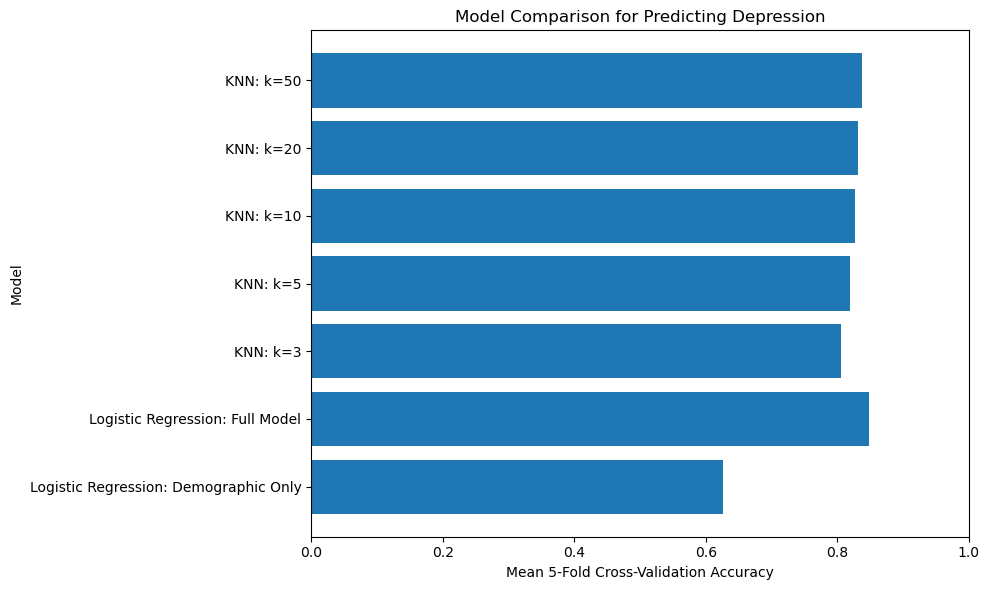

In [18]:
plt.figure(figsize=(10, 6))
plt.barh(model_results["Model"], model_results["Cross-Validation Accuracy"])
plt.xlabel("Mean 5-Fold Cross-Validation Accuracy")
plt.ylabel("Model")
plt.title("Model Comparison for Predicting Depression")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

### Fitting this model

In [19]:
final_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

final_model.fit(X_encoded, y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression(max_iter=1000))])

In [20]:
y_pred = final_model.predict(X_encoded)

final_accuracy = accuracy_score(y, y_pred)

print("Final model accuracy on full dataset:", final_accuracy)

Final model accuracy on full dataset: 0.84762348555452


### Logistic Regression Coefficients

In [21]:
log_reg = final_model.named_steps["logisticregression"]

coefficients = pd.DataFrame({
    "Predictor": X_encoded.columns,
    "Coefficient": log_reg.coef_[0]
})

coefficients["Absolute Coefficient"] = coefficients["Coefficient"].abs()

coefficients_sorted = coefficients.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

coefficients_sorted.head(15)

,Predictor,Coefficient,Absolute Coefficient
14,Have you ever had suicidal thoughts ?_Yes,1.207536,1.207536
1,Academic Pressure,1.157194,1.157194
5,Financial Stress,0.796487,0.796487
0,Age,-0.536533,0.536533
13,Dietary Habits_Unhealthy,0.523468,0.523468
4,Work/Study Hours,0.435528,0.435528
3,Study Satisfaction,-0.332524,0.332524
11,Dietary Habits_Moderate,0.224767,0.224767
8,Sleep Duration_Less than 5 hours,0.166040,0.166040
15,Family History of Mental Illness_Yes,0.123057,0.123057


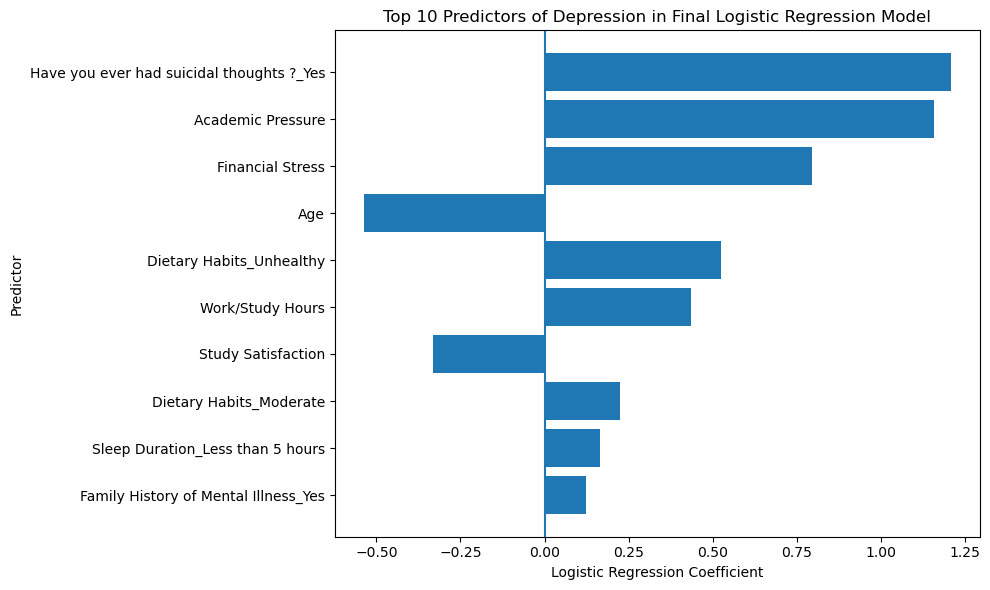

In [22]:
## Final Graph MODEL ESTIMATION
top_coefficients = coefficients_sorted.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_coefficients["Predictor"], top_coefficients["Coefficient"])
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Predictor")
plt.title("Top 10 Predictors of Depression in Final Logistic Regression Model")
plt.axvline(0)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

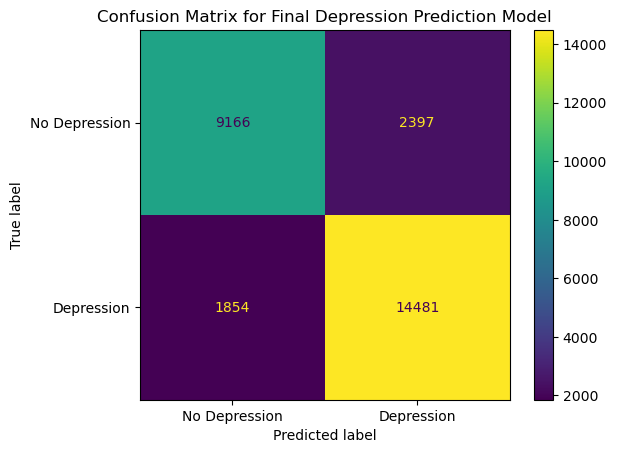

In [23]:
## Confusion Matrix
cm = confusion_matrix(y, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Depression", "Depression"]
)

disp.plot()
plt.title("Confusion Matrix for Final Depression Prediction Model")
plt.show()

### This is for write-up just starter sentences:
The demographic-only model had an average 5-fold cross-validation accuracy of ___.

The full logistic regression model had an average 5-fold cross-validation accuracy of ___.

The best KNN model had an average 5-fold cross-validation accuracy of ___.

Based on these results, I selected ___ as my final model because it had the highest cross-validation accuracy and showed better prediction performance.